# Fase 3 — Modelado y evaluación temporal
**Proyecto 1 · Reingreso a 30 días (Diabetes 130-US)**

Entrena y compara los 3 modelos (ElasticNet, RandomForest, XGBoost) sobre el **dataset limpio** del notebook de Análisis, con validación temporal (sin fuga), y mide la **curva de degradación (E1)** del modelo estático a lo largo de los bloques. Elige el mejor y exporta su configuración para la Fase 4.

## 1. Configuración e imports

In [1]:
import os, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.special import logit, expit

import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
import xgboost as xgb

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

SEED = 42
rng = np.random.default_rng(SEED)
os.makedirs("../resultados", exist_ok=True)
print("sklearn", sklearn.__version__, "| xgboost", xgb.__version__)

sklearn 1.6.1 | xgboost 3.2.0


In [2]:
# ---------------- Ejecución (Fase 3: modelado) ----------------
MODO_RAPIDO   = False      # True: grillas y bootstrap reducidos (para probar)
DIR_PREP      = "../data/processed"  # dataset limpio (notebook de Análisis)
N_BLOQUES     = 10         # 20 periodos del prep -> 10 bloques de 2 periodos
EMBARGO       = 2000       # = label_delay_encuentros calibrado en 03_preprocesamiento (metadata_preparacion.json); evita el leak temporal ya detectado
BLOQUES_TRAIN_INICIAL = 2  # E1: modelo estático entrenado en B1-B2
FRAC_CALIB    = 0.20       # último 20% temporal de la ventana -> calibración (Platt)
B_BOOT        = 100 if MODO_RAPIDO else 500   # remuestreos para IC95%
print(f"N_BLOQUES={N_BLOQUES} | EMBARGO={EMBARGO} | B_BOOT={B_BOOT}")

N_BLOQUES=10 | EMBARGO=2000 | B_BOOT=500


## 2. Carga del dataset limpio

In [3]:
# --- Carga del dataset limpio (train/validacion/test del notebook de Análisis) ---
partes = {n: pd.read_csv(f"{DIR_PREP}/{n}.csv") for n in ["train", "validacion", "test"]}
df = pd.concat(partes.values(), ignore_index=True).sort_values("t_idx").reset_index(drop=True)
df["pos"] = np.arange(len(df))
df["y"]   = df["target"].astype(int)          # target = 1 si readmitted == '<30'
df["bloque"] = df.period // 2 + 1             # 10 bloques pseudo-temporales

# Categóricas con NaN estructural (laboratorio no solicitado) -> categoría explícita
for c in ["max_glu_serum", "A1Cresult"]:
    df[c] = df[c].fillna("None")

print("Forma:", df.shape, "| prevalencia <30:", round(df.y.mean(), 4),
      "| bloques:", sorted(df.bloque.unique()))
print("Split -> train B1-B6 (periodos 0-11) | val B7-B8 (12-15) | test B9-B10 (16-19)")
df.groupby("bloque").agg(n=("y", "size"), prevalencia=("y", "mean")).round(3)

Forma: (95451, 67) | prevalencia <30: 0.114 | bloques: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Split -> train B1-B6 (periodos 0-11) | val B7-B8 (12-15) | test B9-B10 (16-19)


,n,prevalencia
bloque,,
1,9972,0.111
2,10001,0.122
3,9979,0.120
4,9917,0.110
5,9894,0.122
6,7946,0.115
7,9960,0.110
8,7952,0.112
9,9935,0.109


## 3. Definición de variables
`race` se excluye de las *features* (solo se audita en la Fase 4).

In [4]:
# --- Familias de variables según el diccionario del dataset limpio (metadata_preparacion.json) ---
USAR_CONTEXTO = False  # ctx_*/rel_* son proxy del periodo (Secc. 10.5 / 03_preprocesamiento); degradan generalizacion -> excluidas

NUM_ESTATICAS = ["age_num", "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
                 "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses_capped",
                 "service_utilization", "n_meds_active", "n_meds_changed", "meds_per_day", "labs_per_day",
                 "n_comorbidity_groups", "dm_primary", "dm_complicated", "a1c_tested", "a1c_high",
                 "glu_tested", "glu_high"]
NUM_TEMPORALES = ["enc_seq", "is_returning", "prev_readmit30", "hist_n_readmit30", "hist_rate_readmit30",
                  "prev_time_in_hospital", "prev_num_medications", "prev_number_diagnoses_capped",
                  "prev_n_meds_active", "delta_num_medications", "delta_n_meds_active",
                  "roll3_time_in_hospital", "log_gap_prev_encounter", "prev_discharge_snf"]
NUM_CONTEXTO = ["ctx_readmit_rate", "ctx_inpatient_mean", "ctx_a1c_rate", "rel_number_diagnoses", "rel_num_medications"]
VARS_CAT = ["gender", "admission_type_grp", "discharge_grp", "admission_source_grp", "specialty_grp",
            "diag_1_grp", "diag_2_grp", "diag_3_grp", "max_glu_serum", "A1Cresult",
            "insulin", "metformin", "glipizide", "glyburide", "pioglitazone", "rosiglitazone",
            "glimepiride", "change", "diabetesMed"]

VARS_NUM = NUM_ESTATICAS + NUM_TEMPORALES + (NUM_CONTEXTO if USAR_CONTEXTO else [])
VARS_CAT = [c for c in VARS_CAT if df[c].nunique() > 1]
FEATURES = VARS_NUM + VARS_CAT   # 'race' NO se incluye (solo auditoría de equidad)
print(f"{len(VARS_NUM)} numéricas + {len(VARS_CAT)} categóricas = {len(FEATURES)} variables "
      f"(contexto {'incluido' if USAR_CONTEXTO else 'excluido'})")
print("Features con NaN (se imputan por mediana en ElasticNet/RF; XGBoost las maneja nativamente):",
      [c for c in VARS_NUM if df[c].isna().any()])
df[FEATURES].head(3)

35 numéricas + 19 categóricas = 54 variables (contexto excluido)
Features con NaN (se imputan por mediana en ElasticNet/RF; XGBoost las maneja nativamente): ['prev_time_in_hospital', 'prev_num_medications', 'prev_number_diagnoses_capped', 'prev_n_meds_active', 'roll3_time_in_hospital', 'log_gap_prev_encounter']


,age_num,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses_capped,service_utilization,n_meds_active,n_meds_changed,meds_per_day,labs_per_day,n_comorbidity_groups,dm_primary,dm_complicated,a1c_tested,a1c_high,glu_tested,glu_high,enc_seq,is_returning,prev_readmit30,hist_n_readmit30,hist_rate_readmit30,prev_time_in_hospital,prev_num_medications,prev_number_diagnoses_capped,prev_n_meds_active,delta_num_medications,delta_n_meds_active,roll3_time_in_hospital,log_gap_prev_encounter,prev_discharge_snf,gender,admission_type_grp,discharge_grp,admission_source_grp,specialty_grp,diag_1_grp,diag_2_grp,diag_3_grp,max_glu_serum,A1Cresult,insulin,metformin,glipizide,glyburide,pioglitazone,rosiglitazone,glimepiride,change,diabetesMed
0,85,13,68,2,28,0,0,0,8,0,2,0,2.153846,5.230769,1,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,Female,Emergency/Urgent,Home,Transfer,Missing,Circulatory,Circulatory,Other,None,None,Steady,No,Steady,No,No,No,No,Ch,Yes
1,95,12,33,3,18,0,0,0,8,0,2,0,1.500000,2.750000,3,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,Female,Elective,SNF/long-term,Transfer,InternalMedicine,Circulatory,Neoplasms,Respiratory,None,None,Steady,No,No,No,No,Steady,No,Ch,Yes
2,45,1,51,0,8,0,0,0,5,0,2,0,8.000000,51.000000,2,0,0,0,0,0,0,0,0,0.0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0,Male,Emergency/Urgent,Home,Emergency room,Missing,Neoplasms,Neoplasms,Diabetes,None,None,Steady,No,Steady,No,No,No,No,Ch,Yes


## 4. Métricas y utilidades de evaluación

In [5]:
_SK18 = tuple(int(x) for x in sklearn.__version__.split(".")[:2]) >= (1, 8)

def logistica_sin_penalizacion():
    return LogisticRegression(C=np.inf, max_iter=1000) if _SK18 else LogisticRegression(penalty=None, max_iter=1000)

def pendiente_intercepto(y, p):
    lp = logit(np.clip(p, 1e-6, 1 - 1e-6))
    pendiente = logistica_sin_penalizacion().fit(lp.reshape(-1, 1), y).coef_[0, 0]
    def nll(a):
        q = np.clip(expit(a + lp), 1e-9, 1 - 1e-9)
        return -np.sum(y * np.log(q) + (1 - y) * np.log(1 - q))
    intercepto = minimize_scalar(nll, bounds=(-5, 5), method="bounded").x
    return pendiente, intercepto

def ece(y, p, bins=10):
    grupos = pd.qcut(p, bins, labels=False, duplicates="drop")
    d = pd.DataFrame({"y": y, "p": p, "g": grupos}).groupby("g").agg(y=("y", "mean"), p=("p", "mean"), n=("y", "size"))
    return float(np.sum(d.n * (d.y - d.p).abs()) / d.n.sum())

def metricas(y, p):
    y = np.asarray(y); p = np.asarray(p)
    prev = y.mean()
    pend, inter = pendiente_intercepto(y, p)
    brier = brier_score_loss(y, p)
    return {"n": len(y), "prevalencia": prev,
            "ROC_AUC": roc_auc_score(y, p), "PR_AUC": average_precision_score(y, p),
            "lift_PR": average_precision_score(y, p) / prev,
            "Brier": brier, "BSS": 1 - brier / (prev * (1 - prev)),
            "pendiente_cal": pend, "intercepto_cal": inter, "ECE": ece(y, p)}

def ic_bootstrap(y, p, fn, B=B_BOOT, semilla=SEED):
    y = np.asarray(y); p = np.asarray(p)
    r = np.random.default_rng(semilla); vals = []
    for _ in range(B):
        i = r.integers(0, len(y), len(y))
        if y[i].min() == y[i].max(): continue
        vals.append(fn(y[i], p[i]))
    return np.percentile(vals, [2.5, 97.5])

## 5. Modelos y calibración (Sección 6.1)

In [6]:
def construir(nombre, params):
    if nombre == "ElasticNet":
        pre = ColumnTransformer([
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), VARS_NUM),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        kw = dict(solver="saga", max_iter=300, tol=1e-3, random_state=SEED, **params)
        if not _SK18: kw["penalty"] = "elasticnet"
        clf = LogisticRegression(**kw)
    elif nombre == "RandomForest":
        pre = ColumnTransformer([
            ("num", SimpleImputer(strategy="median"), VARS_NUM),
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        clf = RandomForestClassifier(n_estimators=200, max_features="sqrt", n_jobs=-1, random_state=SEED, **params)
    elif nombre == "XGBoost":
        pre = ColumnTransformer([
            ("num", "passthrough", VARS_NUM),   # XGBoost maneja NaN de forma nativa
            ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30), VARS_CAT)])
        clf = xgb.XGBClassifier(learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                                min_child_weight=5, reg_lambda=1.0, tree_method="hist",
                                eval_metric="logloss", n_jobs=-1, random_state=SEED, **params)
    else:
        raise ValueError(nombre)
    return Pipeline([("pre", pre), ("clf", clf)])

def ajustar_pipeline(nombre, params, X, y, semilla=None):
    pipe = construir(nombre, params)
    if semilla is not None:
        pipe.set_params(clf__random_state=semilla)
    pipe.fit(X, y)
    return pipe

class ModeloCalibrado:
    """Entrena en el 80% inicial de la ventana. Calibra en el 20% final probando dos metodos
    y usando el que minimice el Brier en un sub-holdout interno (70/30 temporal de la ventana
    de calibracion): Platt scaling (Platt, 1999) e Isotonic Regression (Zadrozny & Elkan, 2002).
    Comparacion de ambos metodos en clasificadores: Niculescu-Mizil & Caruana (2005)."""
    def __init__(self, nombre, params, semilla=None, bootstrap=False):
        self.nombre, self.params, self.semilla, self.bootstrap = nombre, params, semilla, bootstrap
    def _platt(self, s, y):
        return logistica_sin_penalizacion().fit(logit(np.clip(s, 1e-6, 1 - 1e-6)).reshape(-1, 1), y)
    def fit(self, X, y):
        corte = int(len(X) * (1 - FRAC_CALIB))
        Xf, yf = X.iloc[:corte], y.iloc[:corte]
        if self.bootstrap:  # replica para incertidumbre
            i = np.random.default_rng(self.semilla).integers(0, corte, corte)
            Xf, yf = Xf.iloc[i], yf.iloc[i]
        self.pipe = ajustar_pipeline(self.nombre, self.params, Xf, yf, self.semilla)
        Xc, yc = X.iloc[corte:], y.iloc[corte:]
        s_cal = self.pipe.predict_proba(Xc)[:, 1]
        yc_arr = yc.values

        # --- Seleccion Platt vs. Isotonic dentro de la propia ventana de calibracion ---
        corte_sel = int(len(s_cal) * 0.7)
        self.metodo_cal = "platt"
        y_fit_chk, y_sel_chk = yc_arr[:corte_sel], yc_arr[corte_sel:]
        if len(y_sel_chk) >= 30 and len(set(y_fit_chk)) > 1 and len(set(y_sel_chk)) > 1:
            s_fit, y_fit = s_cal[:corte_sel], y_fit_chk
            s_sel, y_sel = s_cal[corte_sel:], y_sel_chk
            b_platt = brier_score_loss(y_sel, self._platt(s_fit, y_fit).predict_proba(
                logit(np.clip(s_sel, 1e-6, 1 - 1e-6)).reshape(-1, 1))[:, 1])
            b_iso = brier_score_loss(y_sel, IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
                                     .fit(s_fit, y_fit).predict(s_sel))
            if b_iso < b_platt:
                self.metodo_cal = "isotonic"

        if self.metodo_cal == "isotonic":
            self.cal = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(s_cal, yc_arr)
        else:
            self.cal = self._platt(s_cal, yc)
        return self
    def puntaje(self, X):
        return self.pipe.predict_proba(X)[:, 1]
    def predict_proba(self, X):
        s = self.puntaje(X)
        if self.metodo_cal == "isotonic":
            return self.cal.predict(s)
        return self.cal.predict_proba(logit(np.clip(s, 1e-6, 1 - 1e-6)).reshape(-1, 1))[:, 1]

## 6. Ajuste de hiperparámetros (CV temporal)

In [7]:
GRILLAS = {
    "ElasticNet":   [{"C": c, "l1_ratio": l} for c in (0.01, 0.1) for l in (0.2, 0.8)],
    "RandomForest": [{"max_depth": d, "min_samples_leaf": m} for d in (8, 14) for m in (20, 60)],
    "XGBoost":      [{"max_depth": d, "n_estimators": ne} for d in (3, 5) for ne in (200, 400)],
}
if MODO_RAPIDO:
    GRILLAS = {k: v[:2] for k, v in GRILLAS.items()}

def datos_bloques(bloques, embargo=0, marco=None):
    d = (df if marco is None else marco)
    d = d[d.bloque.isin(bloques)] if marco is None else d[d.bloque_g.isin(bloques)]
    if embargo:
        d = d.iloc[embargo:]
    return d[FEATURES], d.y

X_ini, y_ini = datos_bloques(range(1, BLOQUES_TRAIN_INICIAL + 1))
corte_ini = int(len(X_ini) * (1 - FRAC_CALIB))
X_tune, y_tune = X_ini.iloc[:corte_ini], y_ini.iloc[:corte_ini]

MEJORES = {}
tscv = TimeSeriesSplit(n_splits=3)
for nombre, grilla in GRILLAS.items():
    t0 = time.time(); res = []
    for params in grilla:
        scores = []
        for tr, va in tscv.split(X_tune):
            pipe = ajustar_pipeline(nombre, params, X_tune.iloc[tr], y_tune.iloc[tr])
            scores.append(average_precision_score(y_tune.iloc[va], pipe.predict_proba(X_tune.iloc[va])[:, 1]))
        res.append((np.mean(scores), params))
    res.sort(key=lambda r: -r[0])
    MEJORES[nombre] = res[0][1]
    print(f"{nombre:13s} mejor PR-AUC (CV temporal) = {res[0][0]:.3f} con {res[0][1]}  [{time.time()-t0:.0f}s]")

ElasticNet    mejor PR-AUC (CV temporal) = 0.192 con {'C': 0.01, 'l1_ratio': 0.8}  [67s]


RandomForest  mejor PR-AUC (CV temporal) = 0.184 con {'max_depth': 14, 'min_samples_leaf': 20}  [18s]


XGBoost       mejor PR-AUC (CV temporal) = 0.185 con {'max_depth': 3, 'n_estimators': 200}  [26s]


## 7. Experimento E1 — modelo estático y curva de degradación

In [8]:
def evaluar(y, p, ic=False):
    m = metricas(y, p)
    if ic:
        m["AUC_ic_inf"], m["AUC_ic_sup"] = ic_bootstrap(y, p, roc_auc_score)
        m["PR_ic_inf"], m["PR_ic_sup"] = ic_bootstrap(y, p, average_precision_score)
    return m

BLOQUES_PRUEBA = list(range(BLOQUES_TRAIN_INICIAL + 1, N_BLOQUES + 1))
filas_e1, modelos_e1, PRED = [], {}, {}
for nombre in GRILLAS:
    t0 = time.time()
    mod = ModeloCalibrado(nombre, MEJORES[nombre]).fit(X_ini, y_ini)
    modelos_e1[nombre] = mod
    for b in BLOQUES_PRUEBA:
        Xb, yb = datos_bloques([b], EMBARGO)
        p = mod.predict_proba(Xb)
        PRED[("E1", nombre, b)] = (yb.values, p)
        filas_e1.append({"experimento": "E1", "modelo": nombre, "bloque": b, **evaluar(yb, p, ic=True)})
    print(f"E1 {nombre}: {time.time()-t0:.0f}s")

res_e1 = pd.DataFrame(filas_e1)
resumen_e1 = res_e1.groupby("modelo")[["ROC_AUC", "PR_AUC", "lift_PR", "Brier", "BSS", "pendiente_cal", "intercepto_cal", "ECE"]].mean()
resumen_e1["ROC_AUC_peor_bloque"] = res_e1.groupby("modelo").ROC_AUC.min()
MODELO_PRINCIPAL = resumen_e1.PR_AUC.idxmax()
print("Modelo principal:", MODELO_PRINCIPAL)
resumen_e1.round(3)

E1 ElasticNet: 45s


E1 RandomForest: 41s


E1 XGBoost: 31s
Modelo principal: RandomForest


,ROC_AUC,PR_AUC,lift_PR,Brier,BSS,pendiente_cal,intercepto_cal,ECE,ROC_AUC_peor_bloque
modelo,,,,,,,,,
ElasticNet,0.652,0.213,1.867,0.098,0.031,1.014,-0.195,0.023,0.633
RandomForest,0.664,0.215,1.890,0.098,0.030,1.017,-0.246,0.027,0.643
XGBoost,0.653,0.192,1.688,0.099,0.020,0.774,-0.251,0.028,0.639


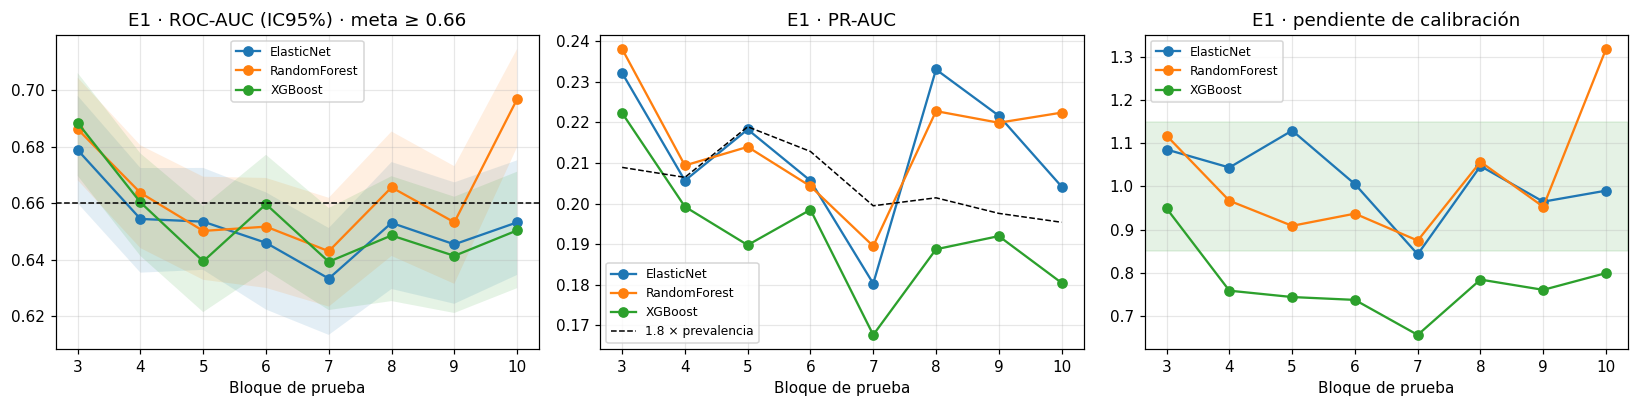

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for nombre, g in res_e1.groupby("modelo"):
    axes[0].plot(g.bloque, g.ROC_AUC, marker="o", label=nombre)
    axes[0].fill_between(g.bloque, g.AUC_ic_inf, g.AUC_ic_sup, alpha=0.12)
    axes[1].plot(g.bloque, g.PR_AUC, marker="o", label=nombre)
    axes[2].plot(g.bloque, g.pendiente_cal, marker="o", label=nombre)
axes[0].axhline(0.66, ls="--", c="k", lw=1); axes[0].set_title("E1 · ROC-AUC (IC95%) · meta ≥ 0.66")
axes[1].plot(res_e1.bloque.unique(), 1.8 * res_e1.groupby("bloque").prevalencia.first(), "k--", lw=1, label="1.8 × prevalencia")
axes[1].set_title("E1 · PR-AUC")
axes[2].axhspan(0.85, 1.15, color="green", alpha=0.1); axes[2].set_title("E1 · pendiente de calibración")
for a in axes: a.set_xlabel("Bloque de prueba"); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig("../resultados/fig_E1_degradacion.png", bbox_inches="tight"); plt.show()

## 8. Modelo elegido → exportar para la Fase 4

In [10]:
import json
os.makedirs("../resultados", exist_ok=True)
with open("../resultados/fase3_modelo.json", "w") as f:
    json.dump({"modelo_principal": MODELO_PRINCIPAL, "mejores": MEJORES}, f, indent=2)
res_e1.to_csv("../resultados/fase3_res_e1.csv", index=False)
resumen_e1.round(3).to_csv("../resultados/fase3_resumen_modelos.csv")
print("Guardado -> resultados/fase3_modelo.json  (modelo principal:", MODELO_PRINCIPAL, ")")
print("Hiperparámetros elegidos:", MEJORES[MODELO_PRINCIPAL])
print("La Etapa 5 (05_drift_adaptacion.ipynb) cargará este JSON para no re-tunear.")

Guardado -> resultados/fase3_modelo.json  (modelo principal: RandomForest )
Hiperparámetros elegidos: {'max_depth': 14, 'min_samples_leaf': 20}
La Etapa 5 (05_drift_adaptacion.ipynb) cargará este JSON para no re-tunear.


### Salida
`resultados/fase3_modelo.json` (modelo + hiperparámetros), `fase3_res_e1.csv` (degradación E1) y `fase3_resumen_modelos.csv`. La Fase 4 los consume.